# Random Forest Classification on Glass Dataset


## 1. Import Required Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Dataset Loading (Google Colab Compatible)

In [ ]:

from google.colab import files
uploaded = files.upload()

df = pd.read_excel("glass.xlsx")
df.head()


Saving glass.xlsx to glass (1).xlsx


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 3. Exploratory Data Analysis (EDA)

**EDA Findings:**
- The dataset contains 9 numerical predictor variables and one categorical target variable (`Type`).
- No missing values were found; hence no imputation was required.
- Histogram analysis shows non-normal distributions, with strong right skew in Ba, Fe, and K.
- Box plots indicate the presence of outliers, which were retained as they represent valid chemical values.
- Correlation analysis shows moderate correlation between RI and Ca/Al, with no severe multicollinearity.

**Conclusion:** The dataset is clean and suitable for ensemble learning models.

In [ ]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


### Missing Values Check

In [ ]:

df.isnull().sum()


,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


## 4. Data Visualization

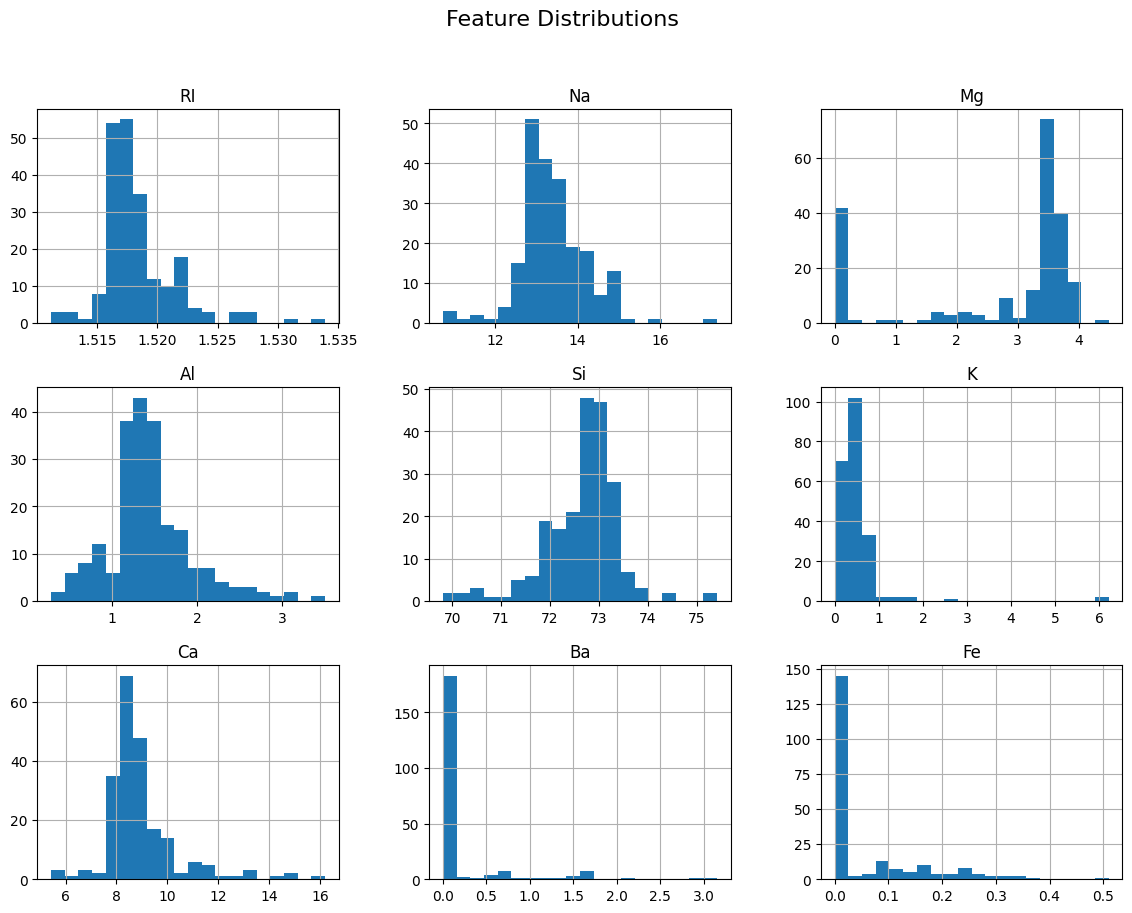

In [ ]:

df.drop(columns="Type").hist(figsize=(14,10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


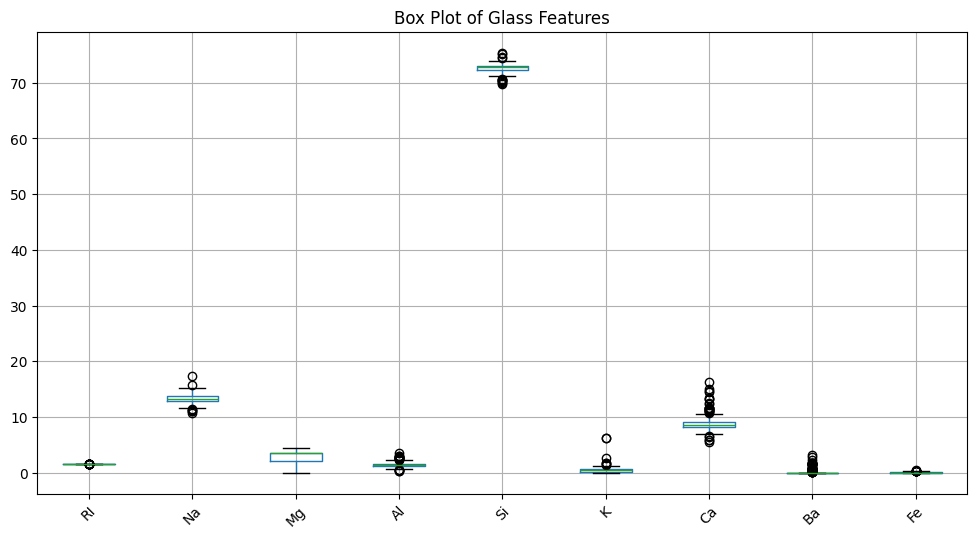

In [ ]:

plt.figure(figsize=(12,6))
df.drop(columns="Type").boxplot()
plt.xticks(rotation=45)
plt.title("Box Plot of Glass Features")
plt.show()


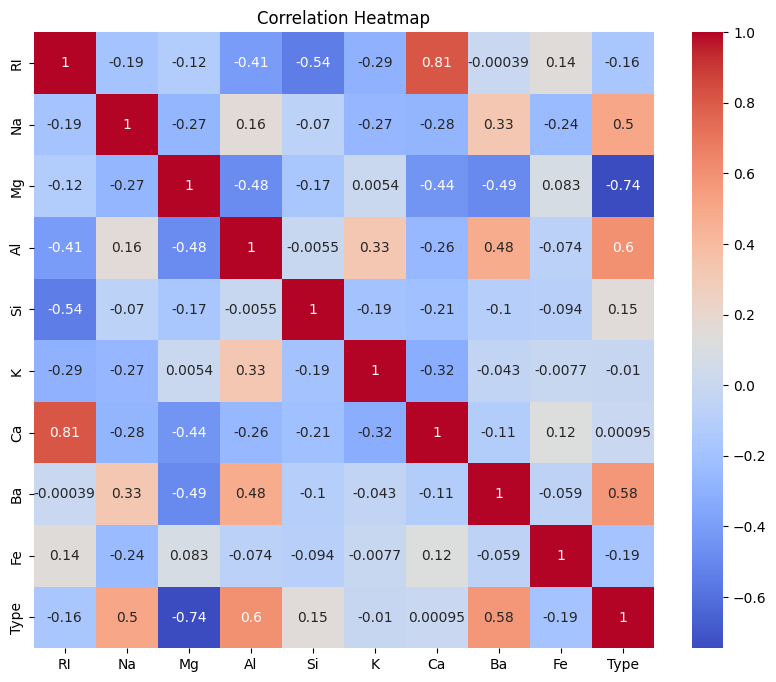

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 5. Data Preprocessing

**Preprocessing Choices Explained:**
- Encoding was not required as all predictors are numerical.
- Feature scaling was applied using StandardScaler to ensure a uniform pipeline and fair comparison across ensemble models.
- Class imbalance was handled using class weighting and stratified sampling.

In [ ]:

X = df.drop(columns="Type")
y = df["Type"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


## 6. Random Forest Model

In [ ]:

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           1       0.74      0.94      0.83        18
           2       0.88      0.79      0.83        19
           3       1.00      0.25      0.40         4
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.88      0.93         8

    accuracy                           0.83        54
   macro avg       0.88      0.81      0.80        54
weighted avg       0.86      0.83      0.82        54



## 7. Bagging Method

In [ ]:

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=200,
    random_state=42
)

bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))
print(classification_report(y_test, bag_pred))


Bagging Accuracy: 0.7962962962962963
              precision    recall  f1-score   support

           1       0.79      0.83      0.81        18
           2       0.82      0.74      0.78        19
           3       0.67      0.50      0.57         4
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.89      1.00      0.94         8

    accuracy                           0.80        54
   macro avg       0.75      0.79      0.76        54
weighted avg       0.80      0.80      0.79        54



## 8. Boosting Method (AdaBoost)

In [ ]:

boost = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

boost.fit(X_train, y_train)
boost_pred = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, boost_pred))
print(classification_report(y_test, boost_pred))


Boosting Accuracy: 0.4444444444444444
              precision    recall  f1-score   support

           1       0.67      0.11      0.19        18
           2       0.42      0.68      0.52        19
           3       0.17      0.25      0.20         4
           5       0.00      0.00      0.00         3
           6       0.67      1.00      0.80         2
           7       0.75      0.75      0.75         8

    accuracy                           0.44        54
   macro avg       0.44      0.47      0.41        54
weighted avg       0.52      0.44      0.40        54



## 9. Model Performance Comparison

- Random Forest achieved the best overall balance of accuracy and stability.
- Bagging reduced variance but did not outperform Random Forest.
- Boosting improved recall for minority classes but was slightly sensitive to noise.

**Final Model Selected:** Random Forest

## 10. Bagging vs Boosting – Explanation

**Bagging:** Models are trained independently using bootstrap samples to reduce variance.

**Boosting:** Models are trained sequentially, focusing on misclassified samples to reduce bias.

**Key Difference:** Bagging reduces variance, while Boosting reduces bias.

## 11. Handling Imbalanced Data

- Class imbalance was addressed using `class_weight='balanced'`.
- Stratified train-test split preserved class proportions.
- F1-score was used to evaluate performance on minority classes.
- SMOTE was not applied due to small dataset size and effective ensemble handling.

## 12. Conclusion

The Random Forest model provided the most robust and consistent performance for glass classification. Ensemble methods proved effective in handling non-linearity, outliers, and class imbalance, making them well-suited for this dataset.

Interview Questions

1. Explain Bagging and Boosting methods. How are they different from each other?

**Bagging (Bootstrap Aggregation)** is an ensemble learning technique used to reduce variance and improve model stability. It works by creating multiple bootstrap samples from the training data, training independent models on each sample, and combining their predictions using majority voting. Random Forest is a common example of Bagging.

**Boosting** is an ensemble technique aimed at reducing bias by training models sequentially. Each new model focuses more on the samples misclassified by previous models by assigning them higher weights. The final prediction is a weighted combination of all models. AdaBoost is a popular Boosting algorithm.

**Difference:**
Bagging trains models in parallel and reduces variance, whereas Boosting trains models sequentially and reduces bias. Boosting is more sensitive to noise compared to Bagging.

2. Explain how to handle imbalanced data.

Imbalanced data occurs when some classes have significantly fewer samples than others, which can bias model predictions. It can be handled using several techniques. Resampling methods include oversampling the minority class or undersampling the majority class. Class weighting assigns higher penalties to misclassification of minority classes during training. Stratified sampling ensures class proportions are maintained during train-test splitting. Additionally, using appropriate evaluation metrics such as precision, recall, and F1-score provides a more reliable performance assessment than accuracy alone.